# Model Training

This notebook handles:
- Data loading and augmentation
- Model architecture setup (MobileNetV3)
- Training loop
- Checkpoint saving

## Import Libraries

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V3_Large_Weights
from pathlib import Path
import matplotlib.pyplot as plt

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.5.1+cu121
CUDA available: True


## Device Setup

In [5]:
# Set device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## Data Loading and Augmentation

In [6]:
# Dataset paths
data_dir = Path('../data')
train_dir = data_dir / 'train'
val_dir = data_dir / 'val'

# IMPROVED Data transforms with stronger augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),  # Increased from 10
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

print(f"Train samples: {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"\nClasses: {train_dataset.classes}")

Train samples: 18,764
Validation samples: 3,917
Number of classes: 12

Classes: ['Chili___Healthy', 'Chili___Leaf_curl', 'Chili___Leaf_spot', 'Chili___Whitefly', 'Chili___Yellowish', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___healthy']


In [7]:
# Create data loaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, 
                         shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, 
                       num_workers=2, pin_memory=True)

print(f"Batch size: {batch_size}")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Batch size: 32
Train batches: 587
Validation batches: 123


## Model Setup

In [8]:
# Load pretrained MobileNetV3 Large
weights = MobileNet_V3_Large_Weights.DEFAULT
model = models.mobilenet_v3_large(weights=weights)

# Freeze pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier with dropout for better generalization
num_classes = len(train_dataset.classes)
model.classifier = nn.Sequential(
    nn.Linear(960, 1280),
    nn.Hardswish(),
    nn.Dropout(p=0.3),  # Add dropout to prevent overfitting
    nn.Linear(1280, num_classes)
)

# Move model to device
model = model.to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: MobileNetV3-Large (with Dropout)")
print(f"Number of classes: {num_classes}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model: MobileNetV3-Large (with Dropout)
Number of classes: 12
Total parameters: 4,217,404
Trainable parameters: 1,245,452


## Training Configuration

In [9]:
# Training configuration
num_epochs = 20  # Maximum epochs
learning_rate = 0.001

# Early stopping configuration
patience = 5  # Stop if no improvement for 5 epochs
early_stop_counter = 0

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler (reduces LR when validation plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                  factor=0.5, patience=3, verbose=True)

print(f"Number of epochs: {num_epochs} (max)")
print(f"Early stopping patience: {patience} epochs")
print(f"Learning rate: {learning_rate}")
print(f"Loss function: CrossEntropyLoss")
print(f"Optimizer: Adam")
print(f"Scheduler: ReduceLROnPlateau")

Number of epochs: 20 (max)
Early stopping patience: 5 epochs
Learning rate: 0.001
Loss function: CrossEntropyLoss
Optimizer: Adam
Scheduler: ReduceLROnPlateau


## Training Loop

In [10]:
# Training history
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
early_stop_counter = 0

print("Starting training...")
print("=" * 60)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100 * correct / total
    
    # Update learning rate based on validation loss
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Early stopping check
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        early_stop_counter = 0  # Reset counter
        improvement_flag = ' [NEW BEST]'
    else:
        early_stop_counter += 1
        improvement_flag = f' (No improvement: {early_stop_counter}/{patience})'
    
    # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}")
    print(f"  Val Accuracy: {val_acc:.2f}%{improvement_flag}")
    print("-" * 60)
    
    # Check if we should stop early
    if early_stop_counter >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        print(f"No improvement for {patience} consecutive epochs")
        break

print(f"\nTraining completed!")
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print(f"Total epochs trained: {len(history['val_acc'])}")

Starting training...
Epoch [1/20]
  Train Loss: 0.5455
  Val Loss: 0.1931
  Val Accuracy: 93.21% [NEW BEST]
------------------------------------------------------------
Epoch [2/20]
  Train Loss: 0.3644
  Val Loss: 0.1878
  Val Accuracy: 93.54% [NEW BEST]
------------------------------------------------------------
Epoch [3/20]
  Train Loss: 0.3068
  Val Loss: 0.1567
  Val Accuracy: 94.13% [NEW BEST]
------------------------------------------------------------
Epoch [4/20]
  Train Loss: 0.2708
  Val Loss: 0.1296
  Val Accuracy: 95.69% [NEW BEST]
------------------------------------------------------------
Epoch [5/20]
  Train Loss: 0.2426
  Val Loss: 0.1439
  Val Accuracy: 95.40% (No improvement: 1/5)
------------------------------------------------------------
Epoch [6/20]
  Train Loss: 0.2199
  Val Loss: 0.1388
  Val Accuracy: 95.58% (No improvement: 2/5)
------------------------------------------------------------
Epoch [7/20]
  Train Loss: 0.2111
  Val Loss: 0.1135
  Val Accuracy: 

## Training Results Visualization

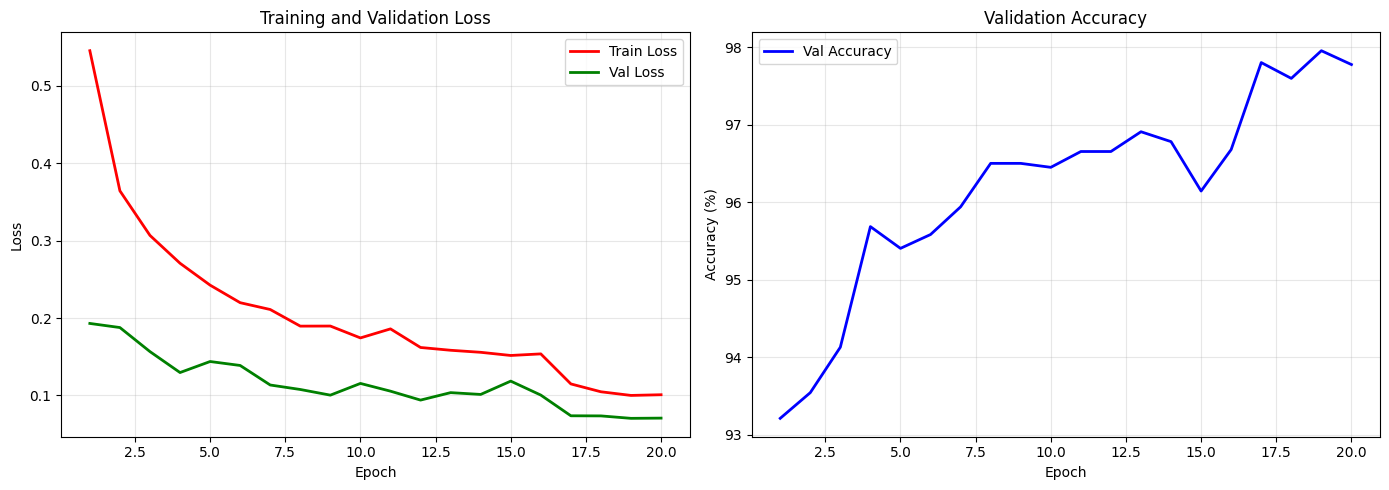

Final Results:
  Train Loss: 0.1009
  Val Loss: 0.0707
  Val Accuracy: 97.78%


In [11]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, num_epochs + 1)

# Loss plot
ax1.plot(epochs, history['train_loss'], 'r-', label='Train Loss', linewidth=2)
ax1.plot(epochs, history['val_loss'], 'g-', label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy plot
ax2.plot(epochs, history['val_acc'], 'b-', label='Val Accuracy', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print final results
print(f"Final Results:")
print(f"  Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Val Loss: {history['val_loss'][-1]:.4f}")
print(f"  Val Accuracy: {history['val_acc'][-1]:.2f}%")

## Save Model

In [12]:
import os
from datetime import datetime

# Create models directory
os.makedirs('../models', exist_ok=True)

# Load best model state
model.load_state_dict(best_model_state)

# Save BEST model with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = f'../models/plant_disease_mobilenetv3_best_{timestamp}.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'classes': train_dataset.classes,
    'num_classes': num_classes,
    'history': history,
    'val_accuracy': best_val_acc  # Best accuracy, not final
}, model_path)

print(f"Best model saved to: {model_path}")
print(f"Classes: {train_dataset.classes}")
print(f"Best validation accuracy: {best_val_acc:.2f}%")

Best model saved to: ../models/plant_disease_mobilenetv3_best_20260301_003955.pth
Classes: ['Chili___Healthy', 'Chili___Leaf_curl', 'Chili___Leaf_spot', 'Chili___Whitefly', 'Chili___Yellowish', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___healthy']
Best validation accuracy: 97.96%


## Summary

**Model Training Completed:**
- Architecture: MobileNetV3-Large (transfer learning)
- Dataset: 18,764 train / 3,917 validation images
- Classes: 12 plant disease categories
- Training: 10 epochs with data augmentation
- Model saved with class names and training history

**Next Steps:**
- Proceed to `04_model_evaluation.ipynb` for detailed performance analysis
- Test model on individual images
- Generate confusion matrix and classification report